# Weather and Daily Step Count Analysis — Fixed Project Notebook

# Weather and Daily Step Count Analysis

## Introduction

This project analyzes whether daily weather conditions are related to walking activity, measured by Apple Health daily step counts. The main research question is whether weather variables such as temperature and precipitation can help explain or predict the number of steps taken each day.

The project uses two datasets: one containing Apple Health step counts and another containing daily weather averages from Open-Meteo. These datasets were cleaned, merged by date, and analyzed using exploratory data analysis, hypothesis testing, and machine learning models.

---

## Data Collection and Preparation

The step count dataset originally contained **104 observations**, while the weather dataset contained **102 observations**. After cleaning and merging the datasets by date, the final dataset contained **102 daily records** from **January 1, 2026 to April 12, 2026**.

The final dataset included the following main variables:

- **steps**: total daily step count
- **temperature_c**: average daily temperature in Celsius
- **precipitation_mm**: average daily precipitation
- **dominant_weather_code**: main weather condition code for the day
- **rainy**: whether the day had precipitation
- **weekday / day_of_week**: calendar-based variables
- **is_weekend**: whether the day was a weekend
- **month**: month of the observation

After cleaning, there were **no missing values** in the merged dataset.

---


## 1. Setup

This section imports all required Python libraries. The notebook only uses common data science libraries: pandas, numpy, matplotlib, scipy, and scikit-learn.

In [2]:
# Core data analysis libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Statistical testing
from scipy.stats import ttest_ind, mannwhitneyu, pearsonr, spearmanr

# Machine learning
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
%matplotlib inline

## 2. Load the Data

The original notebook bug was caused by reading semicolon-separated CSV files with the default comma separator. Here, `sep=None` and `engine="python"` allow pandas to infer the delimiter automatically. This makes the notebook more robust if the same data is exported again.

In [3]:
# Data paths. These files should be in the same folder as this notebook.
STEP_FILE = Path("apple-steps-since-2026-01-01.csv")
WEATHER_FILE = Path("open-meteo-daily-averages.csv")


def read_csv_safely(path: Path) -> pd.DataFrame:
    """Read a CSV file while automatically detecting its delimiter."""
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}. Make sure it is in the same folder as the notebook.")
    return pd.read_csv(path, sep=None, engine="python")


steps_raw = read_csv_safely(STEP_FILE)
weather_raw = read_csv_safely(WEATHER_FILE)

print("Steps data shape:", steps_raw.shape)
print("Weather data shape:", weather_raw.shape)

print("\nSteps columns:", list(steps_raw.columns))
print("Weather columns:", list(weather_raw.columns))

display(steps_raw.head())
display(weather_raw.head())

Steps data shape: (104, 2)
Weather data shape: (102, 5)

Steps columns: ['date', 'total_steps']
Weather columns: ['date', 'avg_temperature_2m_c', 'avg_precipitation_mm', 'dominant_weather_code', 'samples_per_day']


,date,total_steps
0,2026-01-01,4063
1,2026-01-02,4559
2,2026-01-03,2683
3,2026-01-04,6553
4,2026-01-05,8362


,date,avg_temperature_2m_c,avg_precipitation_mm,dominant_weather_code,samples_per_day
0,2026-01-01,0.40,0.05,1,4
1,2026-01-02,5.10,0.00,1,4
2,2026-01-03,11.72,2.00,0,4
3,2026-01-04,15.00,325.00,51,4
4,2026-01-05,14.12,0.00,3,4


## 3. Clean and Merge the Data

This section standardizes column names, converts dates, converts numeric values, removes invalid rows, and merges the step-count data with weather data using the date column.

In [4]:
# Work on copies so the original raw data is preserved.
steps_df = steps_raw.copy()
weather_df = weather_raw.copy()

# Standardize expected column names.
steps_df = steps_df.rename(columns={"total_steps": "steps"})
weather_df = weather_df.rename(columns={
    "avg_temperature_2m_c": "temperature_c",
    "avg_precipitation_mm": "precipitation_mm"
})

# Validate required columns early so errors are easy to understand.
required_steps_cols = {"date", "steps"}
required_weather_cols = {"date", "temperature_c", "precipitation_mm", "dominant_weather_code"}

missing_steps = required_steps_cols - set(steps_df.columns)
missing_weather = required_weather_cols - set(weather_df.columns)

if missing_steps:
    raise ValueError(f"Missing required step columns: {missing_steps}")
if missing_weather:
    raise ValueError(f"Missing required weather columns: {missing_weather}")

# Convert date and numeric columns.
steps_df["date"] = pd.to_datetime(steps_df["date"], errors="coerce")
weather_df["date"] = pd.to_datetime(weather_df["date"], errors="coerce")

steps_df["steps"] = pd.to_numeric(steps_df["steps"], errors="coerce")
weather_df["temperature_c"] = pd.to_numeric(weather_df["temperature_c"], errors="coerce")
weather_df["precipitation_mm"] = pd.to_numeric(weather_df["precipitation_mm"], errors="coerce")
weather_df["dominant_weather_code"] = pd.to_numeric(weather_df["dominant_weather_code"], errors="coerce")

# Drop rows with invalid key values.
steps_df = steps_df.dropna(subset=["date", "steps"])
weather_df = weather_df.dropna(subset=["date", "temperature_c", "precipitation_mm"])

# Merge by date.
df = pd.merge(steps_df, weather_df, on="date", how="inner")
df = df.sort_values("date").reset_index(drop=True)

# Feature engineering.
df["rainy"] = df["precipitation_mm"] > 0
df["weekday"] = df["date"].dt.day_name()
df["day_of_week"] = df["date"].dt.dayofweek  # Monday=0, Sunday=6
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["month"] = df["date"].dt.month

# Keep date as datetime for plotting and analysis.
print("Merged data shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Missing values after cleaning:")
print(df.isna().sum())

display(df.head())

Merged data shape: (102, 11)
Date range: 2026-01-01 to 2026-04-12
Missing values after cleaning:
date                     0
steps                    0
temperature_c            0
precipitation_mm         0
dominant_weather_code    0
samples_per_day          0
rainy                    0
weekday                  0
day_of_week              0
is_weekend               0
month                    0
dtype: int64


,date,steps,temperature_c,precipitation_mm,dominant_weather_code,samples_per_day,rainy,weekday,day_of_week,is_weekend,month
0,2026-01-01,4063,0.40,0.05,1,4,True,Thursday,3,0,1
1,2026-01-02,4559,5.10,0.00,1,4,False,Friday,4,0,1
2,2026-01-03,2683,11.72,2.00,0,4,True,Saturday,5,1,1
3,2026-01-04,6553,15.00,325.00,51,4,True,Sunday,6,1,1
4,2026-01-05,8362,14.12,0.00,3,4,False,Monday,0,0,1


## 4. Data Overview

This section summarizes the cleaned dataset. It helps verify that the merge worked correctly and gives an initial understanding of the scale of each variable.

In [5]:
summary_cols = ["steps", "temperature_c", "precipitation_mm", "dominant_weather_code", "is_weekend", "month"]
display(df[summary_cols].describe().T)

print("Number of rainy days:", int(df["rainy"].sum()))
print("Number of non-rainy days:", int((~df["rainy"]).sum()))

,count,mean,std,min,25%,50%,75%,max
steps,102.0,5115.931373,2289.209813,478.0,3520.25,4942.0000,6516.00,11680.00
temperature_c,102.0,8.874902,3.236050,0.4,6.91,8.6650,11.18,15.43
precipitation_mm,102.0,68.063725,154.642745,0.0,0.05,1.5125,25.00,775.00
dominant_weather_code,102.0,26.882353,26.408555,0.0,3.00,3.0000,51.00,71.00
is_weekend,102.0,0.294118,0.457895,0.0,0.00,0.0000,1.00,1.00
month,102.0,2.235294,1.016463,1.0,1.00,2.0000,3.00,4.00


Number of rainy days: 79
Number of non-rainy days: 23


In [6]:
# Check for potential outliers using the IQR rule.
def iqr_outliers(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_summary = pd.DataFrame({
    "column": ["steps", "temperature_c", "precipitation_mm"],
    "outlier_count": [
        int(iqr_outliers(df["steps"]).sum()),
        int(iqr_outliers(df["temperature_c"]).sum()),
        int(iqr_outliers(df["precipitation_mm"]).sum()),
    ]
})

display(outlier_summary)

display(df.loc[iqr_outliers(df["precipitation_mm"]), ["date", "steps", "temperature_c", "precipitation_mm"]])

,column,outlier_count
0,steps,3
1,temperature_c,1
2,precipitation_mm,21


,date,steps,temperature_c,precipitation_mm
3,2026-01-04,6553,15.00,325.0
6,2026-01-07,5612,15.43,275.0
13,2026-01-14,4459,6.88,225.0
17,2026-01-18,11680,1.75,725.0
19,2026-01-20,11174,4.40,325.0
21,2026-01-22,6669,8.18,375.0
25,2026-01-26,6459,13.05,275.0
26,2026-01-27,5712,12.35,575.0
28,2026-01-29,6057,13.10,275.0
33,2026-02-03,4854,3.98,275.0


## 5. Exploratory Data Analysis

The goal of EDA is to understand patterns before applying statistical tests or machine learning. The charts below examine trends over time and relationships between weather and steps.

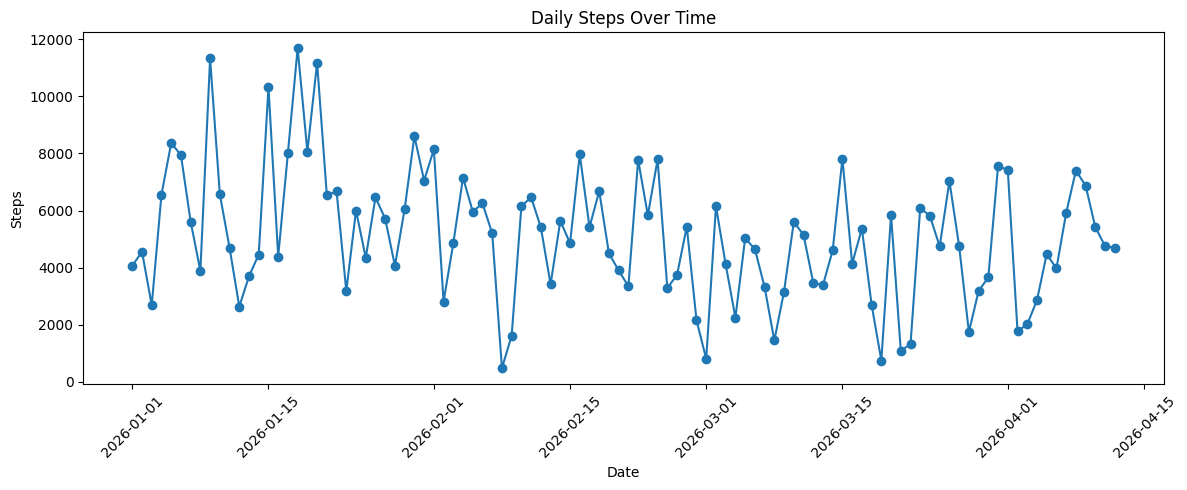

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["steps"], marker="o")
plt.title("Daily Steps Over Time")
plt.xlabel("Date")
plt.ylabel("Steps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

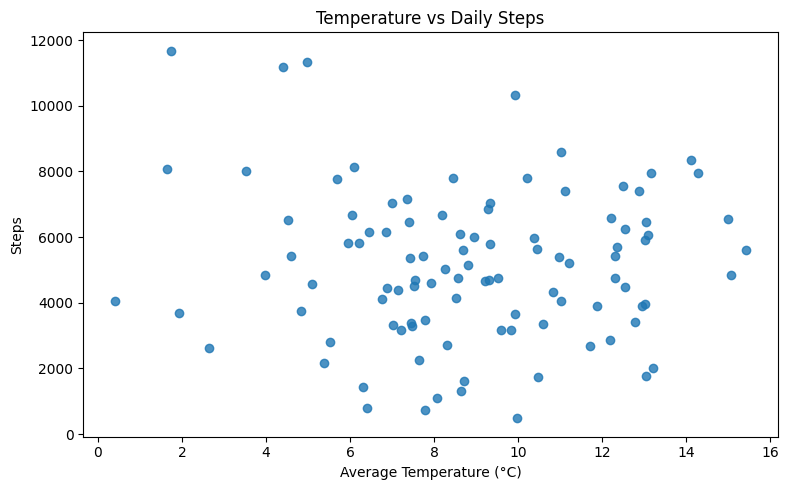

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df["temperature_c"], df["steps"], alpha=0.8)
plt.title("Temperature vs Daily Steps")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Steps")
plt.tight_layout()
plt.show()

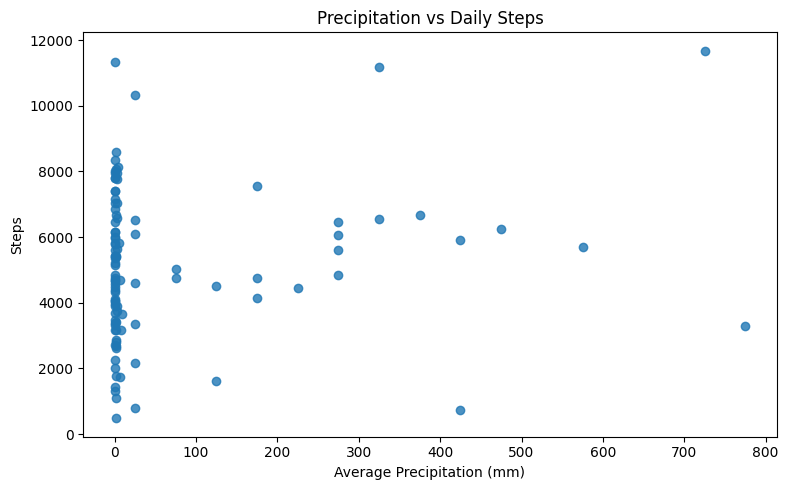

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df["precipitation_mm"], df["steps"], alpha=0.8)
plt.title("Precipitation vs Daily Steps")
plt.xlabel("Average Precipitation (mm)")
plt.ylabel("Steps")
plt.tight_layout()
plt.show()

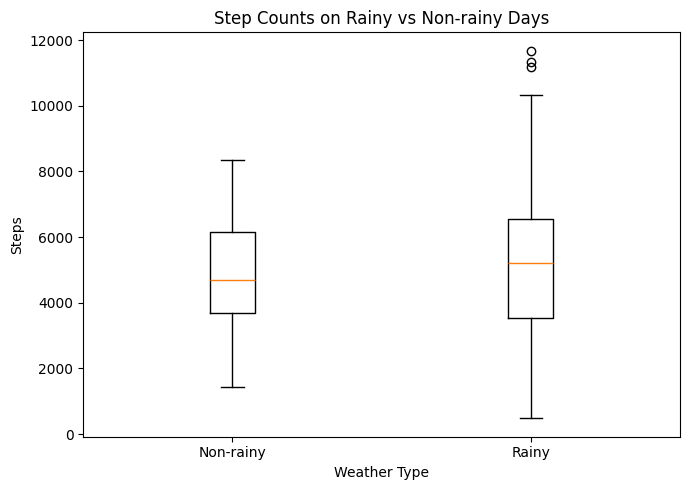

Mean steps on non-rainy days: 4893.78
Mean steps on rainy days: 5180.61
Difference, rainy - non-rainy: 286.82


In [10]:
rainy_steps = df.loc[df["rainy"], "steps"]
non_rainy_steps = df.loc[~df["rainy"], "steps"]

plt.figure(figsize=(7, 5))
plt.boxplot([non_rainy_steps, rainy_steps], labels=["Non-rainy", "Rainy"])
plt.title("Step Counts on Rainy vs Non-rainy Days")
plt.xlabel("Weather Type")
plt.ylabel("Steps")
plt.tight_layout()
plt.show()

print("Mean steps on non-rainy days:", round(non_rainy_steps.mean(), 2))
print("Mean steps on rainy days:", round(rainy_steps.mean(), 2))
print("Difference, rainy - non-rainy:", round(rainy_steps.mean() - non_rainy_steps.mean(), 2))

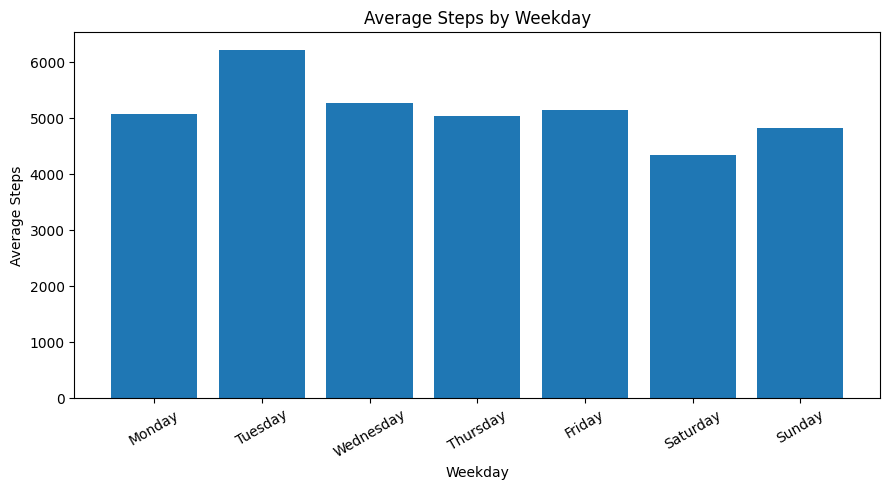

,average_steps
weekday,
Monday,5066.214286
Tuesday,6221.214286
Wednesday,5277.714286
Thursday,5034.866667
Friday,5140.266667
Saturday,4336.266667
Sunday,4816.133333


In [11]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_steps = df.groupby("weekday")["steps"].mean().reindex(weekday_order)

plt.figure(figsize=(9, 5))
plt.bar(weekday_steps.index, weekday_steps.values)
plt.title("Average Steps by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Steps")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(weekday_steps.to_frame("average_steps"))

,steps,temperature_c,precipitation_mm,dominant_weather_code,is_weekend,month
steps,1.000000,-0.042359,0.162428,0.042285,-0.152942,-0.324804
temperature_c,-0.042359,1.000000,0.041513,0.009443,0.015054,0.173957
precipitation_mm,0.162428,0.041513,1.000000,0.165151,-0.107782,-0.185223
dominant_weather_code,0.042285,0.009443,0.165151,1.000000,0.074943,-0.229855
is_weekend,-0.152942,0.015054,-0.107782,0.074943,1.000000,0.020021
month,-0.324804,0.173957,-0.185223,-0.229855,0.020021,1.000000


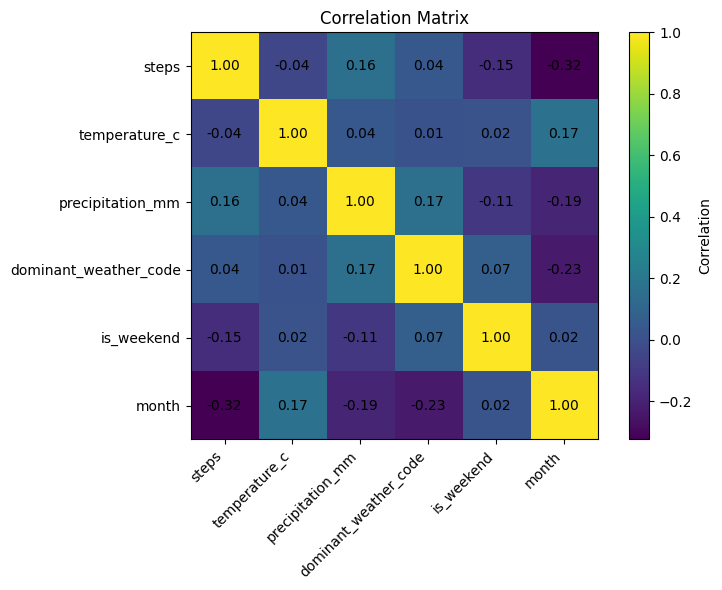

In [12]:
corr_cols = ["steps", "temperature_c", "precipitation_mm", "dominant_weather_code", "is_weekend", "month"]
corr = df[corr_cols].corr(numeric_only=True)

display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 6. Hypothesis Testing

### Hypothesis 1: Rainy and non-rainy days have different average step counts

- **Null hypothesis (H0):** The average daily step count is the same on rainy and non-rainy days.
- **Alternative hypothesis (H1):** The average daily step count is different on rainy and non-rainy days.

A Welch two-sample t-test is used because the rainy and non-rainy groups may have different variances. A Mann-Whitney U test is also included as a non-parametric backup because the dataset is small and step counts may not be normally distributed.

In [13]:
# Welch's t-test
if len(rainy_steps) >= 2 and len(non_rainy_steps) >= 2:
    t_stat, p_value_t = ttest_ind(rainy_steps, non_rainy_steps, equal_var=False)
    print("Welch t-test")
    print("T-statistic:", round(t_stat, 4))
    print("P-value:", round(p_value_t, 4))
else:
    p_value_t = np.nan
    print("Not enough samples for Welch t-test.")

# Mann-Whitney U test
if len(rainy_steps) >= 2 and len(non_rainy_steps) >= 2:
    u_stat, p_value_u = mannwhitneyu(rainy_steps, non_rainy_steps, alternative="two-sided")
    print("\nMann-Whitney U test")
    print("U-statistic:", round(u_stat, 4))
    print("P-value:", round(p_value_u, 4))
else:
    p_value_u = np.nan
    print("Not enough samples for Mann-Whitney U test.")

alpha = 0.05
print("\nInterpretation:")
if pd.notna(p_value_t) and p_value_t < alpha:
    print("At alpha=0.05, the Welch t-test suggests a statistically significant difference in steps between rainy and non-rainy days.")
else:
    print("At alpha=0.05, the Welch t-test does not provide enough evidence for a significant difference in steps between rainy and non-rainy days.")

Welch t-test
T-statistic: 0.6272
P-value: 0.5334

Mann-Whitney U test
U-statistic: 972.0
P-value: 0.6139

Interpretation:
At alpha=0.05, the Welch t-test does not provide enough evidence for a significant difference in steps between rainy and non-rainy days.


### Hypothesis 2: Weather variables are correlated with daily step count

Pearson correlation measures linear association. Spearman correlation measures monotonic association and is less sensitive to outliers.

In [14]:
for feature in ["temperature_c", "precipitation_mm"]:
    pearson_corr, pearson_p = pearsonr(df[feature], df["steps"])
    spearman_corr, spearman_p = spearmanr(df[feature], df["steps"])

    print(f"Feature: {feature}")
    print(f"  Pearson r = {pearson_corr:.4f}, p-value = {pearson_p:.4f}")
    print(f"  Spearman rho = {spearman_corr:.4f}, p-value = {spearman_p:.4f}")

Feature: temperature_c
  Pearson r = -0.0424, p-value = 0.6725
  Spearman rho = 0.0234, p-value = 0.8154
Feature: precipitation_mm
  Pearson r = 0.1624, p-value = 0.1029
  Spearman rho = 0.0469, p-value = 0.6398


## 7. Machine Learning

The machine learning task is to predict daily step count from weather and calendar-related features.

Because the dataset is small and time-ordered, this notebook uses a chronological train/test split: earlier dates are used for training and later dates are used for testing. This is more realistic than randomly mixing past and future days.

Models compared:
1. **DummyRegressor:** baseline model that predicts the training mean.
2. **LinearRegression:** simple interpretable model.
3. **Ridge Regression:** regularized linear model.
4. **RandomForestRegressor:** non-linear model that can capture interactions.

In [15]:
# Define features and target.
feature_cols = [
    "temperature_c",
    "precipitation_mm",
    "dominant_weather_code",
    "rainy",
    "is_weekend",
    "day_of_week",
    "month",
]

target_col = "steps"

model_df = df.dropna(subset=feature_cols + [target_col]).copy()
model_df["rainy"] = model_df["rainy"].astype(int)

X = model_df[feature_cols]
y = model_df[target_col]

# Chronological 75/25 split.
split_index = int(len(model_df) * 0.75)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Training dates:", model_df["date"].iloc[:split_index].min().date(), "to", model_df["date"].iloc[:split_index].max().date())
print("Testing dates:", model_df["date"].iloc[split_index:].min().date(), "to", model_df["date"].iloc[split_index:].max().date())
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training dates: 2026-01-01 to 2026-03-17
Testing dates: 2026-03-18 to 2026-04-12
Train shape: (76, 7)
Test shape: (26, 7)


In [16]:
# Numeric preprocessing: impute missing values and scale for linear models.
numeric_features = feature_cols

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

forest_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features)
    ],
    remainder="drop"
)

models = {
    "Baseline Mean": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Linear Regression": Pipeline(steps=[
        ("preprocess", linear_preprocessor),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline(steps=[
        ("preprocess", linear_preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", forest_preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=3))
    ]),
}

In [17]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Fit a model and return common regression metrics."""
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": rmse,
        "R2": r2_score(y_test, preds),
    }, preds

results = []
predictions = {}

for name, model in models.items():
    result, preds = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(result)
    predictions[name] = preds

results_df = pd.DataFrame(results).sort_values("MAE")
display(results_df)

,model,MAE,RMSE,R2
3,Random Forest,1869.531541,2188.476635,-0.105170
0,Baseline Mean,1887.556680,2305.656066,-0.226688
2,Ridge Regression,2105.883835,2443.105880,-0.377304
1,Linear Regression,2119.198772,2461.562422,-0.398192


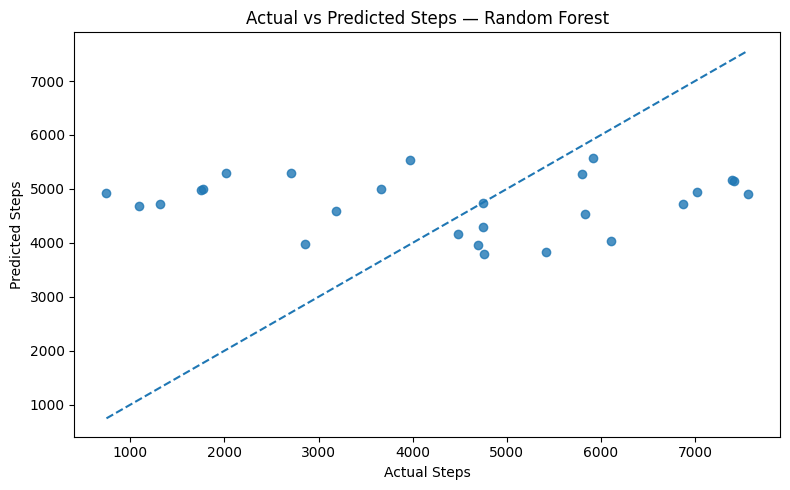

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions[results_df.iloc[0]["model"]], alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title(f"Actual vs Predicted Steps — {results_df.iloc[0]['model']}")
plt.xlabel("Actual Steps")
plt.ylabel("Predicted Steps")
plt.tight_layout()
plt.show()

In [19]:
# Compare actual values with predictions from all models.
comparison_df = pd.DataFrame({
    "date": model_df["date"].iloc[split_index:].values,
    "actual_steps": y_test.values,
})

for name, preds in predictions.items():
    comparison_df[f"pred_{name}"] = np.round(preds, 0).astype(int)

comparison_df.head(10)

,date,actual_steps,pred_Baseline Mean,pred_Linear Regression,pred_Ridge Regression,pred_Random Forest
0,2026-03-18,2702,5369,3764,3798,5288
1,2026-03-19,746,5369,4722,4745,4933
2,2026-03-20,5836,5369,4003,4033,4532
3,2026-03-21,1094,5369,3846,3871,4683
4,2026-03-22,1314,5369,3784,3810,4717
5,2026-03-23,6104,5369,3889,3921,4043
6,2026-03-24,5799,5369,3782,3816,5271
7,2026-03-25,4744,5369,4202,4210,4746
8,2026-03-26,7026,5369,4173,4182,4939
9,2026-03-27,4750,5369,3854,3889,4298


## 8. Cross-Validation Check

Since the dataset is small, one train/test split may be unstable. This section uses 5-fold cross-validation to get a second view of model performance. The result should be interpreted cautiously because the data is time-based, but it is still useful for model comparison.

In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2",
        },
        return_train_score=False,
    )
    cv_results.append({
        "model": name,
        "CV_MAE_mean": -scores["test_MAE"].mean(),
        "CV_MAE_std": scores["test_MAE"].std(),
        "CV_RMSE_mean": -scores["test_RMSE"].mean(),
        "CV_R2_mean": scores["test_R2"].mean(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_MAE_mean")
display(cv_results_df)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean
0,Baseline Mean,1798.097813,326.537958,2232.223302,-0.005641
2,Ridge Regression,1894.484970,354.914522,2327.252667,-0.130763
1,Linear Regression,1898.315850,357.565312,2331.612690,-0.135332
3,Random Forest,2003.451051,294.396168,2480.618815,-0.290895


## 9. Feature Importance / Model Interpretation

For the Random Forest model, feature importance gives an approximate view of which variables helped the prediction most. This does not prove causality; it only describes how the model used the features.

,feature,importance
0,temperature_c,0.328870
1,precipitation_mm,0.257483
6,month,0.177043
5,day_of_week,0.125009
2,dominant_weather_code,0.091991
4,is_weekend,0.015089
3,rainy,0.004516


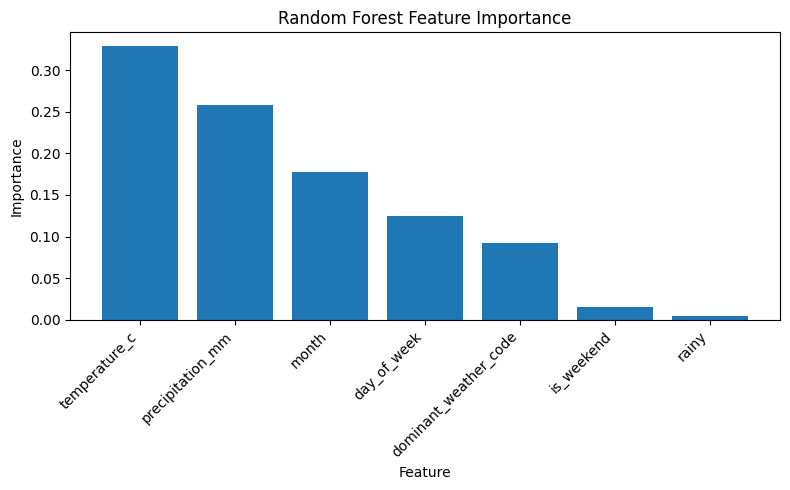

In [21]:
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

importances = rf_model.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances,
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. Limitations and Future Work

Main limitations:

1. **Small dataset:** Around three to four months of daily data is limited for machine learning.
2. **Personal routine is missing:** Weather cannot fully explain steps without schedule, sleep, exams, and location context.
3. **Weather aggregation:** Daily averages may hide important hourly effects. For example, rain at night may not affect walking during the day.
4. **Possible outliers:** Extreme precipitation or step-count values should be checked against the original data source.
5. **Correlation is not causation:** Even if rain and steps are related, this does not prove that rain directly caused lower activity.

Future extensions:

- Add hourly weather data matched with hourly step data.
- Add calendar features such as exam days, weekdays, holidays, and class days.
- Collect more months of Apple Health data.
- Compare Istanbul weather data from multiple weather APIs.
- Try time-series models after collecting more observations.

## 12. Reproducibility Checklist

For the GitHub submission, include these files:

- `fixed_weather_steps_project.ipynb` — final notebook
- `apple-steps-since-2026-01-01.csv` — step count dataset
- `open-meteo-daily-averages.csv` — weather dataset
- `requirements.txt` — Python dependencies
- `README.md` — instructions for running the project
- final report document or markdown report

Also document any AI assistance used for debugging, rewriting, or notebook improvement.

In [22]:
# Optional: save the cleaned merged dataset for the report/repository.
output_path = Path("cleaned_weather_steps_merged.csv")
df.to_csv(output_path, index=False)
print(f"Saved cleaned merged dataset to: {output_path}")

Saved cleaned merged dataset to: cleaned_weather_steps_merged.csv






## Descriptive Statistics

The average daily step count was approximately **5,116 steps**, with a standard deviation of about **2,289 steps**. This shows that daily walking activity varied noticeably across the dataset.

The average temperature was about **8.87°C**, while the average precipitation value was approximately **68.06 mm**. The precipitation variable had high variability, and the outlier analysis showed **21 precipitation outliers**, suggesting that some days had unusually high precipitation values.

The dataset included:

- **79 rainy days**
- **23 non-rainy days**

This means most of the recorded days were classified as rainy.

---

## Exploratory Data Analysis

### Daily Steps Over Time

The time-series plot showed that daily step counts fluctuated throughout the observation period. There was no consistent upward or downward trend, but the number of steps changed significantly from day to day.

This suggests that daily walking behavior may be influenced by many factors beyond weather alone, such as personal schedule, routine, school, work, or other activities.

### Temperature and Steps

The scatter plot comparing temperature and daily steps did not show a strong relationship. The correlation between temperature and steps was very weak and slightly negative:

**Pearson correlation: -0.0424**

This means that temperature did not appear to have a meaningful linear relationship with step count in this dataset.

### Precipitation and Steps

The scatter plot comparing precipitation and steps also showed a weak relationship. The Pearson correlation between precipitation and steps was:

**Pearson correlation: 0.1624**

Although this value is slightly positive, it is still weak. This means precipitation alone does not strongly explain changes in daily step count.

### Rainy vs. Non-Rainy Days

The average number of steps on rainy days was slightly higher than on non-rainy days:

- **Non-rainy days:** 4,893.78 average steps
- **Rainy days:** 5,180.61 average steps
- **Difference:** +286.82 steps on rainy days

However, this difference was small and not statistically significant.

### Average Steps by Weekday

The weekday analysis showed that step counts varied depending on the day of the week. Tuesday had the highest average step count, while Saturday had the lowest.

| Day | Average Steps |
|---|---:|
| Monday | 5,066 |
| Tuesday | 6,221 |
| Wednesday | 5,278 |
| Thursday | 5,035 |
| Friday | 5,140 |
| Saturday | 4,336 |
| Sunday | 4,816 |

This suggests that calendar patterns or personal routine may be more important than weather conditions.

---

## Correlation Analysis

The correlation matrix showed weak relationships between step count and most variables.

The strongest correlations with steps were:

- **Month and steps:** -0.3248
- **Precipitation and steps:** 0.1624
- **Weekend and steps:** -0.1529
- **Temperature and steps:** -0.0424

The negative correlation with month suggests that step counts decreased somewhat over time. The negative correlation with weekend indicates that the user tended to walk less on weekends. However, none of the weather-related correlations were strong.

Overall, the correlation analysis suggests that weather variables alone do not strongly explain daily step count.

---

## Hypothesis Testing

### Hypothesis 1: Rainy and Non-Rainy Days

The first hypothesis tested whether rainy and non-rainy days had significantly different average step counts.

The Welch t-test results were:

- **T-statistic:** 0.6272
- **P-value:** 0.5334

The Mann-Whitney U test results were:

- **U-statistic:** 972.0
- **P-value:** 0.6139

Since both p-values are greater than **0.05**, the results are not statistically significant. Therefore, there is not enough evidence to conclude that step counts are different on rainy and non-rainy days.

### Hypothesis 2: Weather Variables and Step Count

The second hypothesis tested whether temperature and precipitation were correlated with daily steps.

For **temperature**:

- **Pearson r:** -0.0424
- **Pearson p-value:** 0.6725
- **Spearman rho:** 0.0234
- **Spearman p-value:** 0.8154

For **precipitation**:

- **Pearson r:** 0.1624
- **Pearson p-value:** 0.1029
- **Spearman rho:** 0.0469
- **Spearman p-value:** 0.6398

All p-values are greater than **0.05**, so the results are not statistically significant. This means the notebook does not provide strong evidence that temperature or precipitation is meaningfully correlated with daily step count.

---

## Machine Learning Results

Several machine learning models were used to predict daily step count based on weather and calendar-related features. The models included:

- Baseline Mean model
- Linear Regression
- Ridge Regression
- Random Forest Regression

The dataset was split chronologically, with earlier dates used for training and later dates used for testing.

The test period was from **March 18, 2026 to April 12, 2026**.

### Model Performance

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Random Forest | 1,869.53 | 2,188.48 | -0.105 |
| Baseline Mean | 1,887.56 | 2,305.66 | -0.227 |
| Ridge Regression | 2,105.88 | 2,443.11 | -0.377 |
| Linear Regression | 2,119.20 | 2,461.56 | -0.398 |

The Random Forest model performed slightly better than the baseline on the chronological test set, but all models had negative R² values. A negative R² means the models did not predict step count better than a simple average-based prediction in a reliable way.

The cross-validation results also showed weak predictive performance. In cross-validation, the Baseline Mean model had the best average performance, while the Random Forest model performed worse than the baseline.

This suggests that weather and calendar variables are not enough to accurately predict daily step count.

---

## Feature Importance

The Random Forest feature importance results showed that the most useful variables for prediction were:

| Feature | Importance |
|---|---:|
| Temperature | 0.329 |
| Precipitation | 0.257 |
| Month | 0.177 |
| Day of week | 0.125 |
| Dominant weather code | 0.092 |
| Weekend | 0.015 |
| Rainy | 0.005 |

Temperature and precipitation had the highest importance in the Random Forest model. However, this does not mean they have a strong causal effect on step count. Since the model performance was weak overall, feature importance should be interpreted carefully.

---

## Conclusion

The results of this project suggest that daily weather conditions do not strongly explain or predict daily step count in this dataset.

Although rainy days had slightly higher average steps than non-rainy days, the difference was not statistically significant. Similarly, temperature and precipitation showed weak and statistically insignificant correlations with step count.

The machine learning models also had limited success. The Random Forest model performed slightly better than the baseline on the test set, but the negative R² values show that the models were not strong predictors of daily steps.

Overall, the analysis suggests that personal routine, weekday patterns, schedule, or lifestyle factors may have a stronger influence on daily step count than weather alone.

---

## Limitations

This project has several limitations.

First, the dataset covers only about three to four months, which is relatively small for machine learning.

Second, the analysis does not include important personal factors such as class schedule, exams, sleep, location, motivation, or transportation habits.

Third, daily weather averages may hide hourly weather patterns. For example, rain during the night may not affect walking behavior during the day.

Future work could improve the project by collecting more data over a longer time period and adding more personal context variables. Hourly weather data could also make the analysis more accurate.